# Comparison Smoothing

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
#torch.set_default_device("cuda:0")
device = "cuda:0"
aperture_radius = 12.7
NBK7 = dit.materials["NBK7"]
#dit.plotting.wavelength.plot(NBK7)

import os
results_folder = "results/comparison_smoothing/"
try:
    os.mkdir("results")
except:
    pass
try:
    os.mkdir(results_folder)
except:
    pass


In [2]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,NBK7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

det_aperture_radius = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,det_aperture_radius)


#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector})
system = system.to(device)

In [3]:
num_pix = 200
__gridxt = torch.linspace(-det_aperture_radius,det_aperture_radius,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 200 grid_delta tensor(0.0638)


In [4]:

x,weights = light_source.sample(30)
x = x.to(device)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
#dit.plotting.system2D.plot(system,RayPaths)

100%|██████████| 100/100 [00:19<00:00,  5.12it/s]


<Figure size 640x480 with 0 Axes>

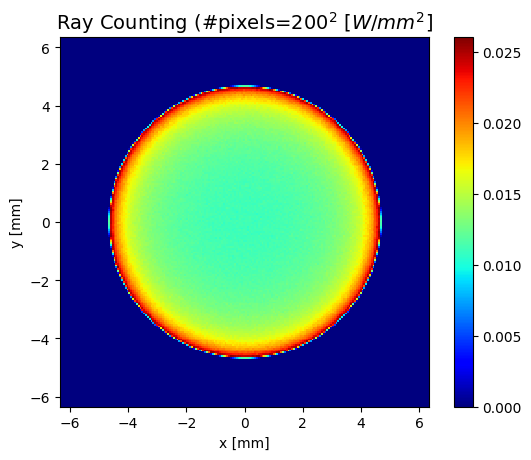

In [5]:
import numpy as np
import torch
import tqdm
from diffinytrace.render import binned_irradiance


grid = dit.target_grid.GridSquare(det_aperture_radius,num_pix)
raycounting_list = []
for k in tqdm.tqdm(range(100)):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=1000000,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    raycounting_list.append(tmp)
raycounting = torch.mean(torch.stack(raycounting_list),dim=0).detach().cpu()


dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting (#pixels=${grid.x_grid_size}^2$",[-det_aperture_radius,det_aperture_radius])



In [6]:
smooth_baseline_dict = {}
sigmas = [0.1,0.3,0.5]

def desired_irradiance_func(x):
        device = x.device
        dtype = x.dtype
        
        x = torch.clamp(x, min=-det_aperture_radius, max=det_aperture_radius)
        k = grid.get_k(x,round_to_bounds=True)
        k = k.cpu()
        
        out = raycounting.reshape(-1)[k]
        out = out.to(device=device,dtype=dtype)
        return out
    
"""
Here we reuse the implementation of calculating the desired irradiance, to smooth the raycounting result.
"""

for sigma in sigmas:

    smoother = dit.nonimaging.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,device="cpu",num_integration_points_desired=[grid.x_grid_size,grid.y_grid_size],desired_irradiance_func=desired_irradiance_func)
    smoother.calc_smooth_desired_irradiance()
    smooth_baseline_dict[sigma] = smoother.desired_smooth_irradiance

    

In [7]:
import gc

tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=100000,method_ray_tracing="monte_carlo",device=device)
tmp = tmp.detach().cpu()
binned_irradiance_100k = tmp

quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
get_smoother = lambda sigma: dit.nonimaging.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma)
all_smoothed_irr100k = []
for sigma in [0.1,0.2,0.5]:
    smoother = get_smoother(sigma)
    tmp = quick_render(100000,smoother)
    tmp = tmp.detach().cpu()
    all_smoothed_irr100k.append(tmp)

gc.collect()


0

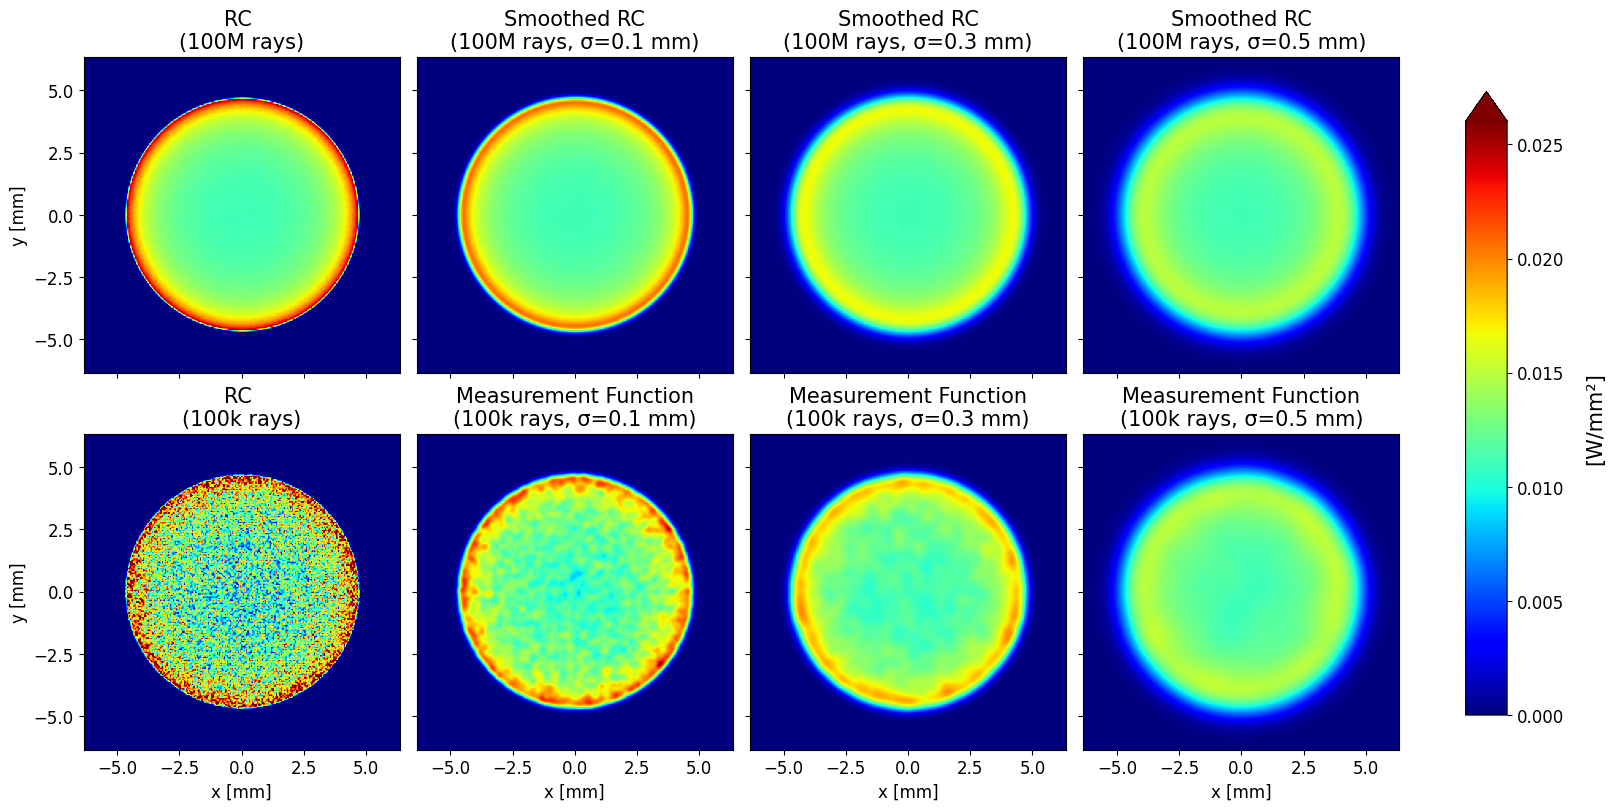

In [8]:
import matplotlib.pyplot as plt
import torch
##raycounting_high

# Example placeholders (replace with your data)
irrs = [raycounting] + [val for val in smooth_baseline_dict.values()]+[binned_irradiance_100k]+all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[-det_aperture_radius, det_aperture_radius,
                 -det_aperture_radius, det_aperture_radius]] * len(irrs)
# sigmas = [...]

cbar_labelsize = 12
cbar_title_fontsize = 15
cmap = "jet"
cbar_title = "[W/mm²]"


# Compute common vmin/vmax
vmin = 0#torch.min(torch.cat(irrs + [raycounting_high.cpu()]))
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Create 2×4 grid, plus an extra column for the shared colorbar
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

# Titles for each column
columns_title = (
    ["RC \n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC \n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each irradiance map
ims = []
for k, ax in enumerate(axes):
    if k < len(irrs):
        img = irrs[k]
        im = ax.imshow(
            img,
            extent=rows_extent[k],
            vmin=vmin, vmax=vmax,
            origin='lower', cmap=cmap
        )
        ims.append(im)
        ax.set_title(columns_title[k], fontsize=cbar_title_fontsize)
        ax.set_xticks([-5, -2.5, 0, 2.5, 5])
        ax.set_yticks([-5, -2.5, 0, 2.5, 5])
        ax.tick_params(labelsize=cbar_labelsize)
        if k < 4:
            if k == 0:
                ax.tick_params(labelbottom=False)
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelbottom=False, labelleft=False)
        else:
            if k == 4:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelleft=False)
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel

    else:
        ax.axis("off")  # Hide unused subplot if fewer than 8 maps

# Add ONE big colorbar on the right
cbar = fig.colorbar(
    ims[0], ax=axes, shrink=0.9, aspect=15,extend='max'   # smaller aspect → thicker bar
)

# Tick labels
cbar.ax.tick_params(labelsize=cbar_labelsize)

# Set label centered along the bar
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

# Offset text (scientific notation scale) adjustments
offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')
plt.savefig(results_folder+"irradiance_image_overviewA.png", dpi=400, bbox_inches='tight')

plt.show()


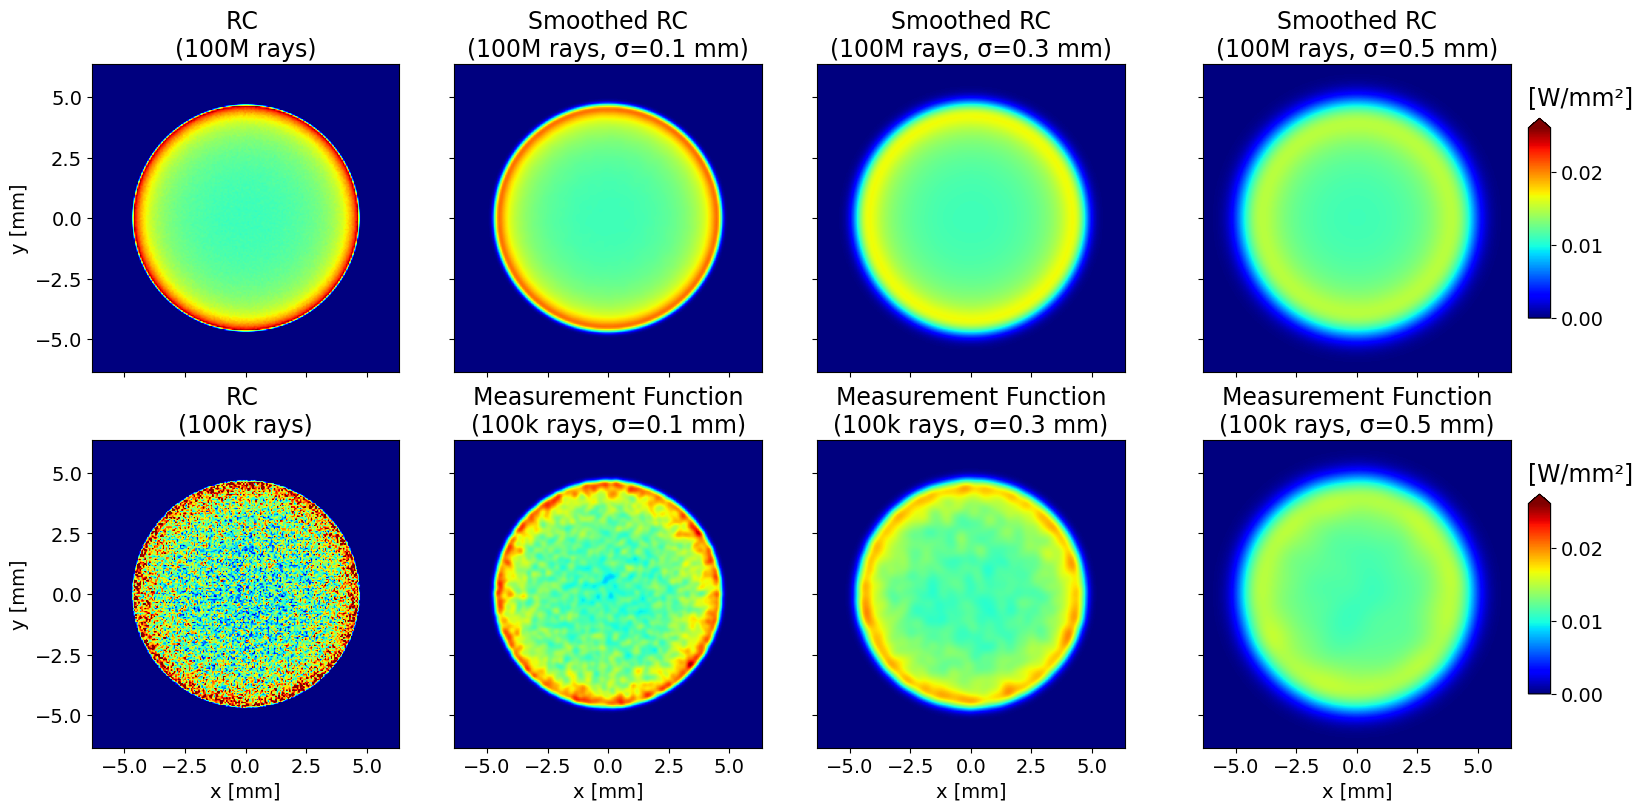

In [9]:
import matplotlib.pyplot as plt
import torch
##raycounting_high

# Example placeholders (replace with your data)
irrs = [raycounting] + [val for val in smooth_baseline_dict.values()]+[binned_irradiance_100k]+all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[-det_aperture_radius, det_aperture_radius,
                 -det_aperture_radius, det_aperture_radius]] * len(irrs)
# sigmas = [...]

cbar_labelsize = 14
cbar_title_fontsize = 17
cmap = "jet"
cbar_title = "[W/mm²]"


# Compute common vmin/vmax
vmin = 0#torch.min(torch.cat(irrs + [raycounting_high.cpu()]))
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Create 2×4 grid, plus an extra column for the shared colorbar
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

# Titles for each column
columns_title = (
    ["RC \n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC \n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each irradiance map
ims = []
for k, ax in enumerate(axes):
    if k < len(irrs):
        img = irrs[k]
        im = ax.imshow(
            img,
            extent=rows_extent[k],
            vmin=vmin, vmax=vmax,
            origin='lower', cmap=cmap
        )
        ims.append(im)
        ax.set_title(columns_title[k], fontsize=cbar_title_fontsize)
        ax.set_xticks([-5, -2.5, 0, 2.5, 5])
        ax.set_yticks([-5, -2.5, 0, 2.5, 5])
        ax.tick_params(labelsize=cbar_labelsize)
        if k < 4:
            if k == 0:
                ax.tick_params(labelbottom=False)
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelbottom=False, labelleft=False)
        else:
            if k == 4:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelleft=False)
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
        if k == 3 or k == 7:
            cbar = plt.colorbar(im,ax=ax,shrink=0.65,aspect=9,extend='max') # Add a colorbar for reference
            cbar.ax.tick_params(labelsize=cbar_labelsize)
            cbar.ax.set_title("[W/mm²]", fontsize=cbar_title_fontsize, pad=10,loc="left") # Set label above
    else:
        ax.axis("off")  # Hide unused subplot if fewer than 8 maps

"""# Add ONE big colorbar on the right
cbar = fig.colorbar(
    ims[0], ax=axes, shrink=0.9, aspect=15,extend='max'   # smaller aspect → thicker bar
)

# Tick labels
cbar.ax.tick_params(labelsize=cbar_labelsize)

# Set label centered along the bar
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

# Offset text (scientific notation scale) adjustments
offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')
"""
plt.savefig(results_folder+"irradiance_image_overviewA2.png", dpi=400, bbox_inches='tight')

plt.show()


In [10]:
import tqdm
    
def run_all_simulations():
    global smoother_baseline_irrs
    
    L2_diff_RC = {}
    L2_diff_smooth = {}

    RMSE_RC = {}
    RMSE_smooth = {}
    #2**np.linspace(8,20,20)
    all_num_rays = np.array(2**np.linspace(5,19,50),dtype=np.int64)
    #,5000,10000

    RMSE_RC_RC = []
    for num_rays in tqdm.tqdm(all_num_rays):
            
        irr = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
            
        #_L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
            

        _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            
        RMSE_RC_RC.append(_RMSE_RC)
            
        #L2_diff_RC[sigma].append(_L2_diff_RC)
        
    for sigma in sigmas:
        quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
        get_smoother = lambda sigma: dit.nonimaging.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma)
        smoother = get_smoother(sigma)
        
        baseline_smooth_irr = smooth_baseline_dict[sigma]
        
        RMSE_RC[sigma] = []
        RMSE_smooth[sigma] = []
        
        L2_diff_RC[sigma] = []
        L2_diff_smooth[sigma] = []
        

        for num_rays in tqdm.tqdm(all_num_rays):
            
            #print("after baseline render")
            
            irr = quick_render(num_rays,smoother)
                
            _L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
            _L2_diff_smooth = torch.sqrt(smoother.get_integral_over_distribution((irr-baseline_smooth_irr)**2.0))
            

            _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            _RMSE_smooth = torch.sqrt(torch.mean((irr-baseline_smooth_irr)**2.0))
            
            RMSE_RC[sigma].append(_RMSE_RC)
            RMSE_smooth[sigma].append(_RMSE_smooth)
            
            L2_diff_RC[sigma].append(_L2_diff_RC)
            L2_diff_smooth[sigma].append(_L2_diff_smooth)
                

    return RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np


gc.collect()
RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays = run_all_simulations()
# Get the number of different ray counts


100%|██████████| 50/50 [00:06<00:00,  7.69it/s]


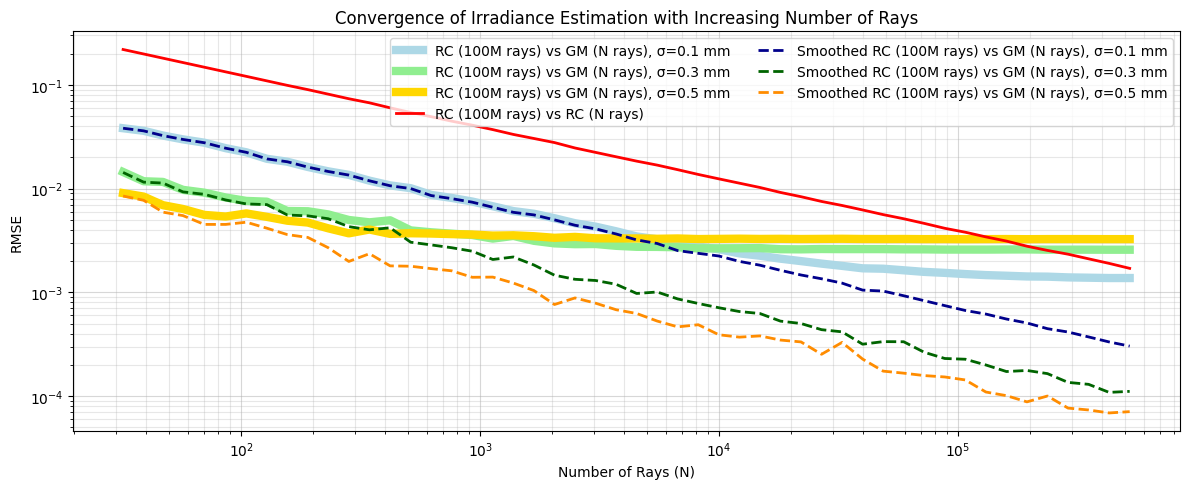

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VA.png", dpi=400, bbox_inches='tight')
        

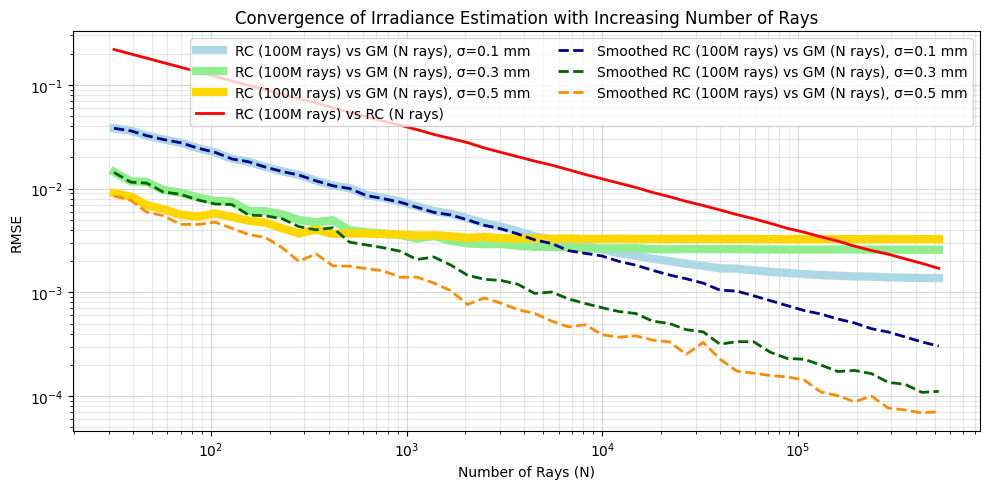

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB.png", dpi=400, bbox_inches='tight')


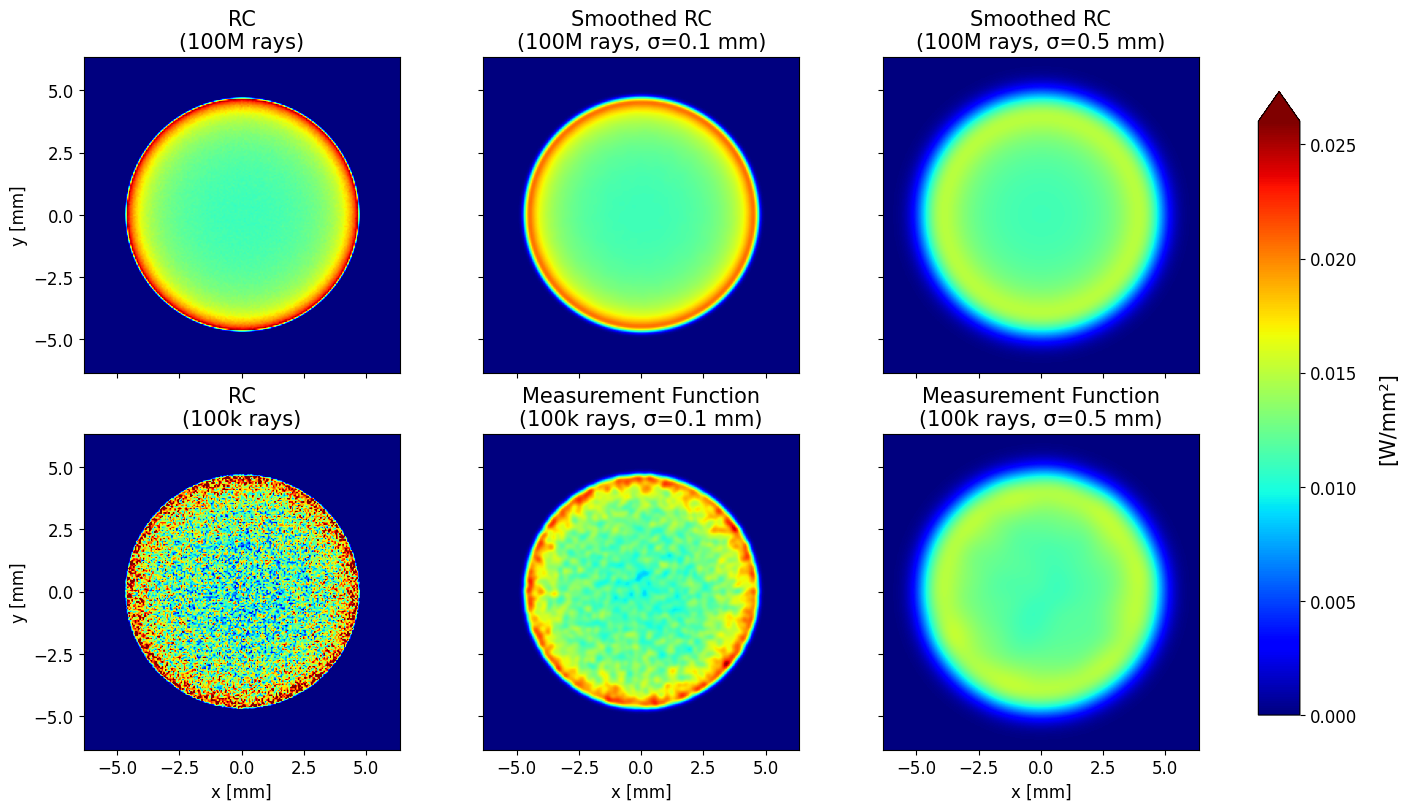

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch


# Prepare data (right-hand grid only)
irrs = [raycounting] + list(smooth_baseline_dict.values()) + [binned_irradiance_100k] + all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[
    -det_aperture_radius, det_aperture_radius,
    -det_aperture_radius, det_aperture_radius
]] * len(irrs)

cbar_labelsize = 12
cbar_title_fontsize = 15
cmap = "jet"
cbar_title = "[W/mm²]"

# Color scale across the plotted images
vmin = 0.0
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Figure layout: 2 rows × 3 cols
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Titles corresponding to `irrs`
columns_title = (
    ["RC\n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC\n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Remove 3rd and 7th images (0-based indices: 2 and 6)
remove_indices = {2, 6}
irrs        = [irr  for i, irr  in enumerate(irrs)         if i not in remove_indices]
rows_extent = [ext  for i, ext  in enumerate(rows_extent)  if i not in remove_indices]
columns_title = [t for i, t in enumerate(columns_title)    if i not in remove_indices]

# Plot the 2×3 grid
axes = []
ims = []
for r in range(2):
    for c in range(3):
        idx = r * 3 + c
        ax = fig.add_subplot(gs[r, c])
        if idx < len(irrs):
            img = irrs[idx]
            im = ax.imshow(
                img,
                extent=rows_extent[idx],
                vmin=vmin, vmax=vmax,
                origin='lower', cmap=cmap
            )
            ims.append(im)
            axes.append(ax)

            ax.set_title(columns_title[idx], fontsize=cbar_title_fontsize)
            ax.set_xticks([-5, -2.5, 0, 2.5, 5])
            ax.set_yticks([-5, -2.5, 0, 2.5, 5])
            ax.tick_params(labelsize=cbar_labelsize)
            
            # Clean ticks: hide duplicate left labels and top-row bottom labels
            if c != 0:
                ax.tick_params(labelleft=False)
            else:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
        
            if r == 0:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
        
            
        else:
            ax.axis("off")

# Shared colorbar for everything (thicker, center label, extend at max)
mappable = ims[0]  # there should be at least one image
cbar = fig.colorbar(
    mappable,
    ax=axes,
    shrink=0.9,
    aspect=15,
    extend='max',
)
cbar.ax.tick_params(labelsize=cbar_labelsize)
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')

plt.savefig(results_folder + "irradiance_image_overviewD.png",
            dpi=400, bbox_inches='tight')
plt.show()


In [15]:
"""import matplotlib.pyplot as plt
import torch

# --- Assume these are already defined ---
# raycounting_high, det_aperture_radius, vmin, vmax, cmap,
# cbar_labelsize, cbar_title_fontsize, cbar_title

fig, ax = plt.subplots(figsize=(6, 6))  # single square plot

im = ax.imshow(
    raycounting_high.cpu(),
    extent=[-det_aperture_radius, det_aperture_radius,
            -det_aperture_radius, det_aperture_radius],
    vmin=vmin, vmax=vmax,
    origin='lower', cmap=cmap
)

ax.set_title("RC High-Resolution\n(100M rays, $1000^2$ pixels)",
             fontsize=cbar_title_fontsize)
ax.set_xticks([-5, -2.5, 0, 2.5, 5])
ax.set_yticks([-5, -2.5, 0, 2.5, 5])
ax.tick_params(labelsize=cbar_labelsize)

# Optional: add colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, aspect=15,extend='max')
cbar.ax.tick_params(labelsize=cbar_labelsize)
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)
plt.savefig(results_folder + "irradiance_image_overviewE.png",
            dpi=400, bbox_inches='tight')

plt.show()
"""

'import matplotlib.pyplot as plt\nimport torch\n\n# --- Assume these are already defined ---\n# raycounting_high, det_aperture_radius, vmin, vmax, cmap,\n# cbar_labelsize, cbar_title_fontsize, cbar_title\n\nfig, ax = plt.subplots(figsize=(6, 6))  # single square plot\n\nim = ax.imshow(\n    raycounting_high.cpu(),\n    extent=[-det_aperture_radius, det_aperture_radius,\n            -det_aperture_radius, det_aperture_radius],\n    vmin=vmin, vmax=vmax,\n    origin=\'lower\', cmap=cmap\n)\n\nax.set_title("RC High-Resolution\n(100M rays, $1000^2$ pixels)",\n             fontsize=cbar_title_fontsize)\nax.set_xticks([-5, -2.5, 0, 2.5, 5])\nax.set_yticks([-5, -2.5, 0, 2.5, 5])\nax.tick_params(labelsize=cbar_labelsize)\n\n# Optional: add colorbar\ncbar = fig.colorbar(im, ax=ax, shrink=0.8, aspect=15,extend=\'max\')\ncbar.ax.tick_params(labelsize=cbar_labelsize)\ncbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)\nplt.savefig(results_folder + "irradiance_image_overviewE.png"

In [16]:
gc.collect()

81783

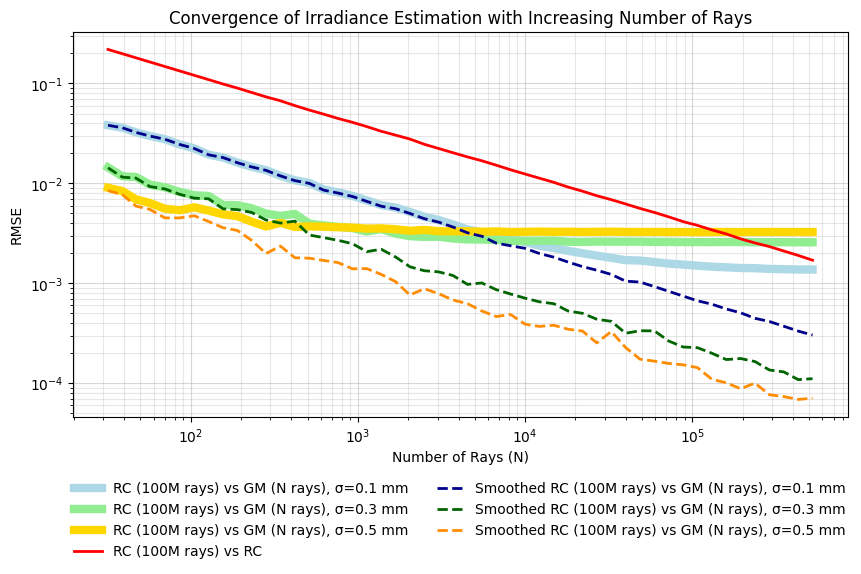

In [36]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False)
plt.grid(True, 'minor', alpha=0.3)
plt.grid(True, alpha=0.5)
#plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB2.png", dpi=400, bbox_inches='tight')


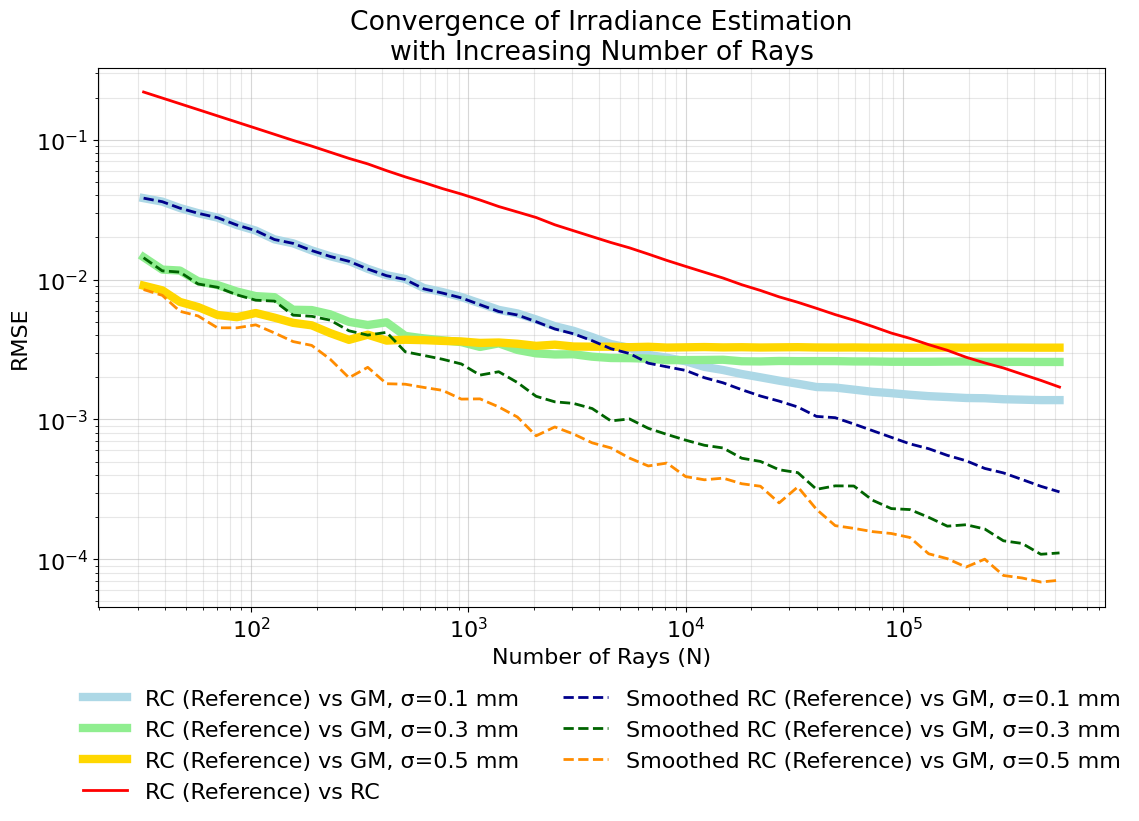

In [38]:
import matplotlib.pyplot as plt


label_font_size = 16
title_font_size = 16
plt.figure(figsize=(13,7))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (Reference) vs GM, σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (Reference) vs RC")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (Reference) vs GM, σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation\nwith Increasing Number of Rays', fontsize=title_font_size*1.2)
plt.xlabel('Number of Rays (N)', fontsize=label_font_size)
plt.ylabel('RMSE', fontsize=label_font_size)
plt.tick_params(axis='both', labelsize=label_font_size)  # <-- Increase tick font size
plt.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False, fontsize=title_font_size)
plt.grid(True, 'minor', alpha=0.3)
plt.grid(True, alpha=0.5)
#plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB3.png", dpi=400, bbox_inches='tight')
